<a href="https://colab.research.google.com/github/MarioHervas/pytorch-tutorial/blob/main/neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What is clasification?

Categorizing items, for example, spam detectors inside emails. This is binary classification (either it is spam or not). There is also multiclass classifications like food images. Another one is multilabel, while food may just be steak or sushi, an article may have various tags, not only one.

###Inputs and outputs

Inputs --> ML ALgorithm --> Outputs
Normal image representation is W = 224, H = 224, C = 3. This is the way we build tensors around the data, we can have various dimensions, the value of red, blue and green for each pixel. That's why tensors are so helpful!

An example would be -> Shape = [batch_size, colour_channels, width, height] but for each problem this could change.


In [1]:
import torch
import sklearn
from sklearn.datasets import make_circles
from torch import nn

n_samples = 1000
#Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

print(f"First five samples of X: {X[:5]}")
print(f"First five samples of y: {y[:5]}")
#X has 2 features that relates to 1 feature (binary classification)

First five samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First five samples of y: [1 1 1 1 0]


In [2]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],"X2":X[:,1],"label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


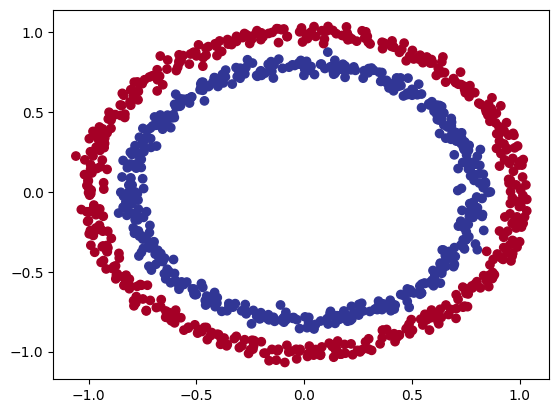

In [3]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu)

**Note**: This data is often referred as a toy dataset, good enough to practice but samll enough to experiment


###1.1 Check input and output shapes

In [4]:
X_sample = X[0]
y_sample = y[0]
print(X_sample)
print(y_sample)
print(X_sample.shape)
print(y_sample.shape)
#Two features of X precict one feature of y

[0.75424625 0.23148074]
1
(2,)
()


### 1.2 Turn data into tensor

In [5]:
import torch
#Defaukt NumPy 64 to PyTorch defaukt 32 (float)
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
#Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #Test size is percentage that is used for test size


### 2. Building a model

Let's build a model to classify the blu and red dots.

THE PLAN

1. Setup the device agnostic code
2. Construct a model by subclassing nn.Module
3. Define a loss function and optimizer
4. Create a training and test loop

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

For the model:

1. Subclasses `nn.Module`
2. Create 2 `nn.Linear()`
3. Define a `forward()`
4. Instatiate an instance of our model class and send it to the target `device`

In [7]:
# 1. Construct a model class that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [8]:
#Replicating with nn.Sequential

model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

In [9]:
# Make predictions
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.7009, -0.2851],
                      [ 0.2092, -0.4888],
                      [-0.3569, -0.2019],
                      [ 0.5398, -0.5407],
                      [-0.1612,  0.1360]], device='cuda:0')),
             ('0.bias',
              tensor([-0.3049, -0.4439, -0.1057,  0.0055,  0.4161], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0586, -0.2766,  0.2890, -0.0245,  0.0824]], device='cuda:0')),
             ('1.bias', tensor([0.3983], device='cuda:0'))])

In [10]:
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)} Shape {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"First 10 preds:\n {torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 labels { y_test[:10]}")

Length of predictions: 200 Shape torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])
First 10 preds:
 tensor([[0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.]], device='cuda:0')

First 10 labels tensor([1., 1., 0., 0., 1., 0., 0., 1., 0., 0.])


In [11]:
X_test[:10], y_test[:10]

(tensor([[ 0.7628,  0.2606],
         [-0.6851,  0.2873],
         [-0.5375, -0.8470],
         [ 0.0091,  0.9840],
         [-0.7646, -0.2763],
         [-0.7812, -0.6949],
         [-0.5971, -0.7740],
         [-0.8157, -0.0105],
         [ 0.2252, -1.0193],
         [-0.4552,  0.8561]]),
 tensor([1., 1., 0., 0., 1., 0., 0., 1., 0., 0.]))

### 2.1 Setup loss function and optimizer

For regression it usually MAE or MSE (Mean Absolute/Squared Error)
For clasissifcation you want BCE loss

In [12]:
loss_fn = nn.BCEWithLogitsLoss() #Uses sigmoid activation

optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)


In [13]:
# Calculate acurracy so we can see how well our model gets it right
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

## 3. Training the model via loop
1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (gradient descent)

### 3.1 From raw logits -> prediction probabilities -> prediction labels
Our model outputs are going to be raw **logits**

We can convert logits into prediction probabilities by passing them to some kind of activation function.
We later can convert this to prediction labels.

In [14]:

model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.4171],
        [0.6313],
        [0.5138],
        [0.5886],
        [0.5953]], device='cuda:0')

In [15]:
#Turning it into prediction
y_pred_probs = torch.sigmoid(y_logits)
y_preds = torch.round(y_pred_probs)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0')

### 3.2 Building the test and training loops

In [16]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

X_train, y_train = X_train.to(device),y_train.to(device)
X_test, y_test = X_test.to(device),y_test.to(device)
for epoch in range (epochs):
  model_0.train()
  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  # 2. Calculate loss
  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_true=y_train,y_pred = y_pred)
  # 3. Optimizer zero grad
  optimizer.zero_grad()
  # 4. Loss backward
  loss.backward()
  #5 Optimizer
  optimizer.state

  model_0.eval()
  with torch.inference_mode():
    # 1. Fprward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)

    if epoch % 100 ==0:
      print(f"Epoch: {epoch} Loss: {loss:.5f} Acc{acc:.2f} Test Loss: {test_loss:.5f} Test Acc{test_acc:.2f}")

Epoch: 0 Loss: 0.73428 Acc48.50 Test Loss: 0.69408 Test Acc56.00


## 4. Making predictions and evaluating model

The model isn't learning anything. Let's visualize some predictions to see how did it go

In [17]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("Helper already downloades")
else:
  print("Downloading")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

Helper already downloades


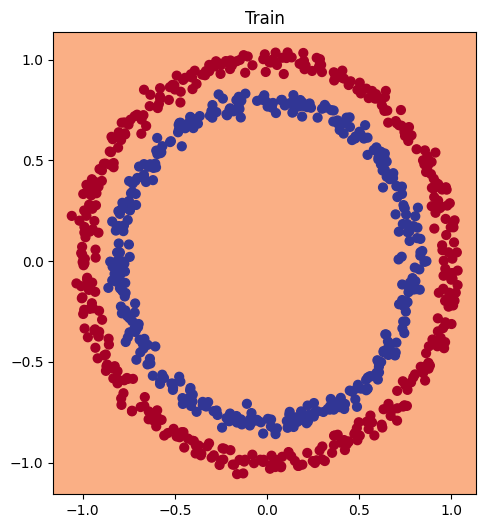

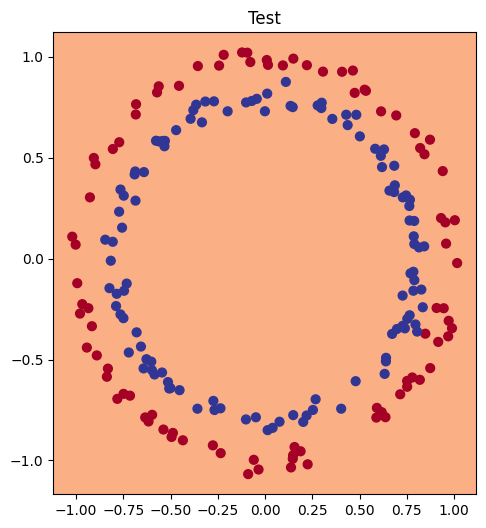

In [18]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)